In [2]:
import pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

path = "/Users/luanabreno/Desktop/Datasets/"

df = pd.read_csv(path + 'winequality-red.csv') 

In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


## Random Forest

In [4]:
X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred, zero_division=0)}')

Accuracy: 0.6729166666666667
Classification Report:               precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        16
           5       0.74      0.77      0.75       204
           6       0.62      0.76      0.68       192
           7       0.67      0.33      0.44        60
           8       0.50      0.20      0.29         5

    accuracy                           0.67       480
   macro avg       0.42      0.34      0.36       480
weighted avg       0.65      0.67      0.65       480



## XGBoost

In [ ]:
#SMOTE was used to balanced the three classes
#0 - Bad, 1 - Medium, 2 - Good

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

df['quality_group'] = df['quality'].apply(lambda q: 0 if q <= 4 else (1 if q <= 6 else 2))
X = df.drop(['quality', 'quality_group'], axis=1)
y = df['quality_group'] 

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())
print(y_train_res.value_counts())

XG = XGBClassifier(n_estimators=500,
                   max_depth=6,
                   learning_rate=0.05,
                   subsample=0.8,
                   colsample_bytree=0.8,
                   random_state=42,
                   eval_metric='mlogloss')

XG.fit(X_train_res, y_train_res)
y_pred = XG.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred, zero_division=0)}')

Accuracy: 0.8833333333333333
Classification Report:               precision    recall  f1-score   support

           0       0.33      0.05      0.09        19
           1       0.91      0.96      0.93       396
           2       0.75      0.68      0.71        65

    accuracy                           0.88       480
   macro avg       0.66      0.56      0.58       480
weighted avg       0.86      0.88      0.87       480



### Three classes are not ideal, best way is to predict the closest quality score using regression + feature engineering

In [18]:
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

df['acidity_ratio'] = df['volatile acidity'] / df['fixed acidity']

df['sulfur_ratio'] = df['free sulfur dioxide'] / df['total sulfur dioxide'] 

df['alcohol_density'] = df['alcohol'] / df['density'] 

X = df.drop(['quality', 'quality_group'] , axis = 1)
y = df['quality'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor(n_estimators=500,
                     max_depth=6,
                     learning_rate=0.05,
                     random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f'R2: {r2_score(y_test, y_pred)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred)}')

R2: 0.5188058614730835
RMSE: 0.5607701539993286


#### Model explains 51% of the variation, and in average is wrong by 0.56 points, so if the quality score is 6, model usually is gonna guess between 5.44 and 6.56.

In [35]:
importance = model.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feat_imp)

                 Feature  Importance
13       alcohol_density    0.214583
10               alcohol    0.181643
9              sulphates    0.138829
11         acidity_ratio    0.065867
6   total sulfur dioxide    0.059845
8                     pH    0.049255
1       volatile acidity    0.049195
12          sulfur_ratio    0.041793
5    free sulfur dioxide    0.040003
3         residual sugar    0.039644
4              chlorides    0.038233
7                density    0.032259
2            citric acid    0.029745
0          fixed acidity    0.019106


Text(0.5, 1.0, 'Feature Importance Table')

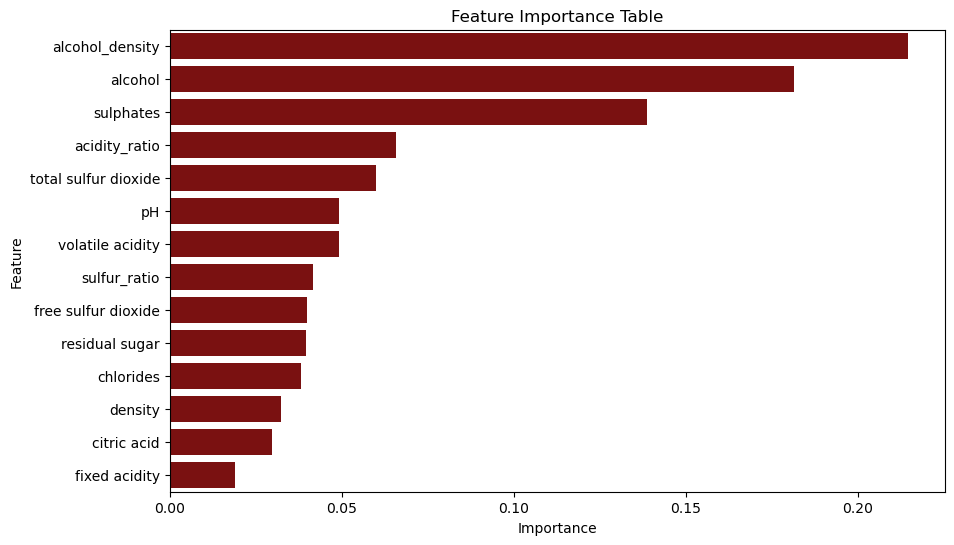

In [37]:
plt.figure(figsize=(10, 6))
sns.barplot(y=feat_imp['Feature'], x=feat_imp['Importance'], orient='h', color='darkred')
plt.title('Feature Importance Table')

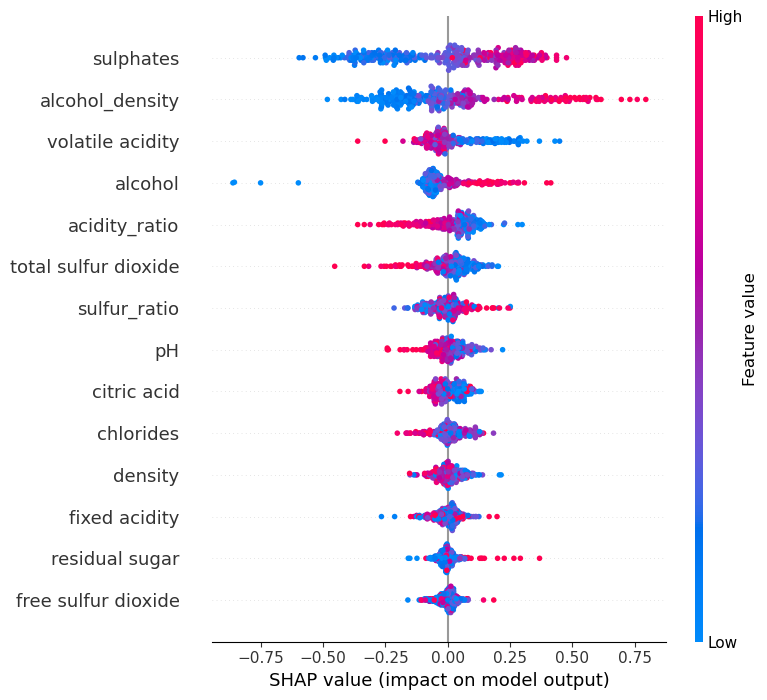

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [ ]:
import joblib

joblib.dump(model, 'wine_model.pkl')